In [1]:
import numpy as np
import xml.etree.ElementTree as ET
from datetime import datetime, timezone
import matplotlib.pyplot as plt
from ipywidgets import interact, IntSlider
import scipy
import xarray as xr
from scripts import geometry, io, doppler

In [2]:
'''
Create SLC from S1 SAFE file:
par_S1_SLC data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/measurement/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.tiff data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/calibration-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/noise-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml  data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.tops_par - - - 

Extract single burst:
ScanSAR_burst_copy  data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc.tops_par data/S1_data/desert/iw1_vv_burst1.slc data/S1_data/desert/iw1_vv_burst1.slc.par 1 - - -
'''

'\nCreate SLC from S1 SAFE file:\npar_S1_SLC data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/measurement/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.tiff data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/calibration-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/calibration/noise-s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml  data/S1_data/desert/iw1_vv.slc.par data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.slc.tops_par - - - \n\nExtract single burst:\nScanSAR_burst_copy  data/S1_data/desert/iw1_vv.slc data/S1_data/desert/iw1_vv.s

In [3]:
# Windowing for CDE DC estimation
WIN_AZ = 186
WIN_RG = 256
STRIDE_AZ = 31
STRIDE_RG = 256

In [4]:
SLC_PATHS = []
SLC_PAR_PATHS = []

for i in range(1,10):
    SLC_PATHS.append(f"data/S1_data/desert/iw1_vv_burst{i}.slc")
    SLC_PAR_PATHS.append(f"data/S1_data/desert/iw1_vv_burst{i}.slc.par")

ANNOT_XML = "data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE/annotation/s1a-iw1-slc-vv-20260203t172441-20260203t172506-063058-07e9d7-004.xml"

In [5]:
dc_img_ffts = []
freqs = []
spectrums = []
geoms=[]
dcas = []

for SLC_PATH, SLC_PAR_PATH in zip(SLC_PATHS, SLC_PAR_PATHS):
    dc_img_fft = doppler.fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[0]
    dc_img_ffts.append(dc_img_fft)
    freqs.append(doppler.fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[1])
    spectrums.append(doppler.fft_doppler(SLC_PATH, SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)[2])
    geom = geometry.estimate_geom_doppler_s1_burst(SLC_PAR_PATH, WIN_AZ, WIN_RG, STRIDE_AZ, STRIDE_RG)
    geoms.append(geom)
    dcas.append(dc_img_fft-geom)

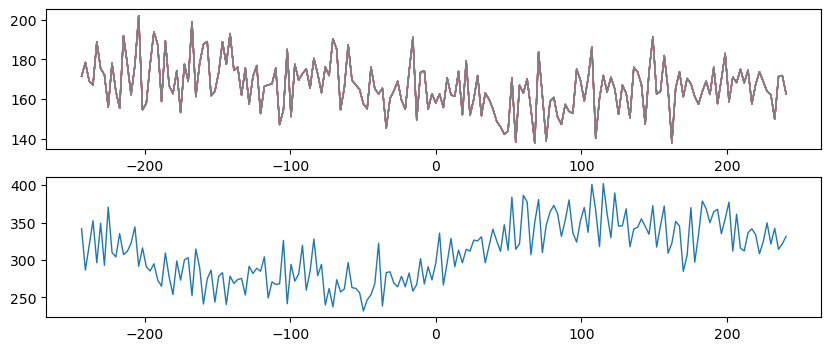

In [ ]:
fig,ax = plt.subplots(2,1,figsize=(10,4))
for i in range(2,10):
    ax[0].plot(freqs[0], spectrums[0][1,13], lw=1)

for i in range(1):
    ax[1].plot(freqs[0], spectrums[0][i,1], lw=1)


In [8]:
dca = np.concatenate(dcas)
fft = np.concatenate(dc_img_ffts)

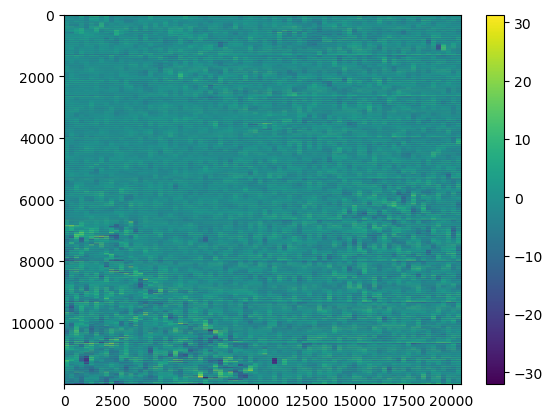

In [11]:
plt.imshow(fft, aspect='auto')
plt.colorbar()

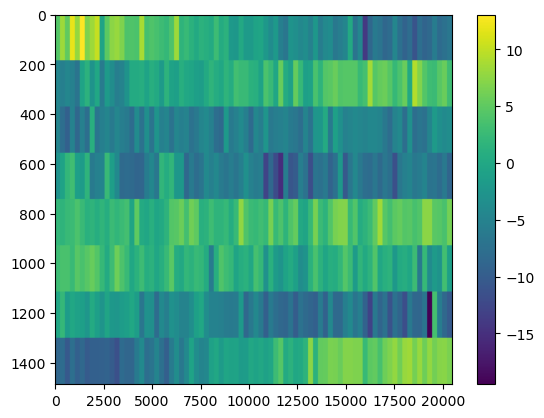

In [ ]:
plt.imshow(dc_img_ffts[0], aspect='auto')
plt.colorbar()

In [ ]:
from scripts import s1_ocn

In [ ]:
safe_dir = 'data/S1_data/desert/S1A_IW_SLC__1SDV_20260203T172441_20260203T172508_063058_07E9D7_CE72.SAFE'

In [ ]:
rvl = s1_ocn.compute_rvl(safe_dir, 'iw1', 'vv')
nrcs = s1_ocn.compute_nrcs(safe_dir, 'iw1', 'vv')

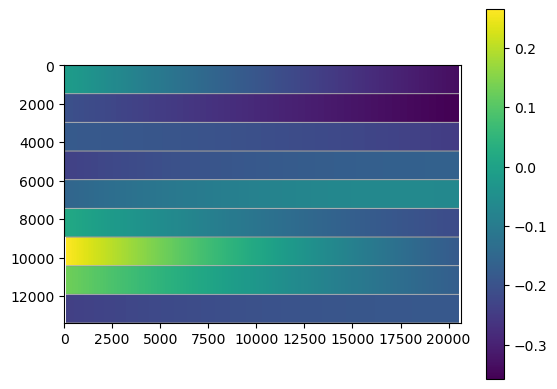

In [ ]:
plt.imshow(rvl.values)
plt.colorbar()